# Frank Energie marktprijzen
Deze notebook haalt marktprijzen op via de Frank Energie GraphQL API.

In [1]:
import requests
from datetime import date, timedelta

GRAPHQL_URL = "https://graphql.frankenergie.nl/"

def build_query(target_date: str) -> str:
    return f"""
    query MarketPrices {{
      marketPrices(date: "{target_date}") {{
        electricityPrices {{
          from
          till
          marketPrice
          marketPriceTax
          sourcingMarkupPrice
          energyTaxPrice
          perUnit
        }}
        gasPrices {{
          from
          till
          marketPrice
          marketPriceTax
          sourcingMarkupPrice
          energyTaxPrice
          perUnit
        }}
      }}
    }}
    """

def fetch_market_prices(target_date: str):
    query = build_query(target_date)
    payload = {"query": query}
    response = requests.post(GRAPHQL_URL, json=payload, timeout=30)
    response.raise_for_status()
    data = response.json()
    errors = data.get("errors")
    if errors:
        message = errors[0].get("message", errors)
        raise RuntimeError(f"Frank Energie API fout: {message}")
    return data["data"]["marketPrices"]

def daterange(start: date, stop: date):
    current = start
    while current <= stop:
        yield current
        current += timedelta(days=1)

START_DATE = date.fromisoformat("2025-01-01")
END_DATE = date.today()

electricity_prices = []
gas_prices = []
skipped_days = []

for day in daterange(START_DATE, END_DATE):
    day_str = day.isoformat()
    try:
        daily_prices = fetch_market_prices(day_str)
    except RuntimeError as exc:
        skipped_days.append((day_str, str(exc)))
        continue
    electricity_prices.extend(daily_prices.get("electricityPrices") or [])
    gas_prices.extend(daily_prices.get("gasPrices") or [])

market_prices = {
    "electricityPrices": electricity_prices,
    "gasPrices": gas_prices,
    "skippedDays": skipped_days,
}

len(electricity_prices), len(gas_prices), len(skipped_days)

(10512, 10512, 0)

In [2]:
# Zet de resultaten om naar DataFrames en toon een overzicht
try:
    import pandas as pd
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Installeer pandas om de prijzen in DataFrames te tonen.') from exc

electricity_df = pd.DataFrame(market_prices.get("electricityPrices", []))
gas_df = pd.DataFrame(market_prices.get("gasPrices", []))
skipped_days = market_prices.get("skippedDays", [])

print(f'Elektriciteitsprijzen: {len(electricity_df)} rijen')
display(electricity_df.tail())
print()
print(f'Gasprijzen: {len(gas_df)} rijen')
display(gas_df.tail())

if skipped_days:
    print(f'Overgeslagen dagen: {len(skipped_days)} (eerste 5 getoond)')
    for day, reason in skipped_days[:5]:
        print(f'- {day}: {reason}')
else:
    print('Geen overgeslagen dagen.')

electricity_df, gas_df

Elektriciteitsprijzen: 10512 rijen


,from,till,marketPrice,marketPriceTax,sourcingMarkupPrice,energyTaxPrice,perUnit
10507,2026-03-14T18:00:00.000Z,2026-03-14T19:00:00.000Z,0.16984,0.03567,0.01815,0.11085,KWH
10508,2026-03-14T19:00:00.000Z,2026-03-14T20:00:00.000Z,0.15027,0.03156,0.01815,0.11085,KWH
10509,2026-03-14T20:00:00.000Z,2026-03-14T21:00:00.000Z,0.13745,0.02886,0.01815,0.11085,KWH
10510,2026-03-14T21:00:00.000Z,2026-03-14T22:00:00.000Z,0.13524,0.02840,0.01815,0.11085,KWH
10511,2026-03-14T22:00:00.000Z,2026-03-14T23:00:00.000Z,0.12805,0.02689,0.01815,0.11085,KWH



Gasprijzen: 10512 rijen


,from,till,marketPrice,marketPriceTax,sourcingMarkupPrice,energyTaxPrice,perUnit
10507,2026-03-14T18:00:00.000Z,2026-03-14T19:00:00.000Z,0.49128,0.10317,0.07986,0.7268,M3
10508,2026-03-14T19:00:00.000Z,2026-03-14T20:00:00.000Z,0.49128,0.10317,0.07986,0.7268,M3
10509,2026-03-14T20:00:00.000Z,2026-03-14T21:00:00.000Z,0.49128,0.10317,0.07986,0.7268,M3
10510,2026-03-14T21:00:00.000Z,2026-03-14T22:00:00.000Z,0.49128,0.10317,0.07986,0.7268,M3
10511,2026-03-14T22:00:00.000Z,2026-03-14T23:00:00.000Z,0.49128,0.10317,0.07986,0.7268,M3


Geen overgeslagen dagen.


(                           from                      till  marketPrice  \
 0      2024-12-31T23:00:00.000Z  2025-01-01T00:00:00.000Z      0.01362   
 1      2025-01-01T00:00:00.000Z  2025-01-01T01:00:00.000Z      0.00624   
 2      2025-01-01T01:00:00.000Z  2025-01-01T02:00:00.000Z      0.00416   
 3      2025-01-01T02:00:00.000Z  2025-01-01T03:00:00.000Z      0.00328   
 4      2025-01-01T03:00:00.000Z  2025-01-01T04:00:00.000Z      0.00068   
 ...                         ...                       ...          ...   
 10507  2026-03-14T18:00:00.000Z  2026-03-14T19:00:00.000Z      0.16984   
 10508  2026-03-14T19:00:00.000Z  2026-03-14T20:00:00.000Z      0.15027   
 10509  2026-03-14T20:00:00.000Z  2026-03-14T21:00:00.000Z      0.13745   
 10510  2026-03-14T21:00:00.000Z  2026-03-14T22:00:00.000Z      0.13524   
 10511  2026-03-14T22:00:00.000Z  2026-03-14T23:00:00.000Z      0.12805   
 
        marketPriceTax  sourcingMarkupPrice  energyTaxPrice perUnit  
 0             0.00286      

In [3]:
import pandas as pd
#TODO add a column with the prices from Prices NL 2025.csv to the electricity df
loaded_prices = pd.read_csv('Prices NL 2025.csv', sep=',')
split = loaded_prices['MTU (CET/CEST)'].str.split(' - ', n=1, expand=True)
#loaded_prices['Start'] = pd.to_datetime(split[0], dayfirst=True)
#loaded_prices['End'] = pd.to_datetime(split[1], dayfirst=True, format='%d/%m/%Y %H:%M:%S')

#loaded_prices['MTU (CET/CEST)'] = pd.to_datetime(loaded_prices['MTU (CET/CEST)'], format='%m/%d/%y %H:%M', errors='coerce')
#split['Day-ahead Price (EUR/MWh)'] = pd.to_numeric(split['Day-ahead Price (EUR/MWh)'], errors='coerce')
split[2100:2116]

FileNotFoundError: [Errno 2] No such file or directory: 'Prices NL 2025.csv'

In [ ]:
def parse_mtu(col):

    s = col.astype(str).str.replace(r'\s*\((?:CET|CEST)\)\s*','', regex=True).str.strip()

    dt = pd.to_datetime(s, dayfirst=True, errors='raise') # let pandas handle seconds flexibly

    return dt.dt.tz_localize('Europe/Amsterdam', ambiguous='infer', nonexistent='shift_forward')

loaded_prices['Start'] = parse_mtu(split[0])

loaded_prices['End'] = parse_mtu(split[1])

loaded_prices['Start_utc'] = loaded_prices['Start'].dt.tz_convert('UTC')
loaded_prices['End_utc'] = loaded_prices['End'].dt.tz_convert('UTC')

In [ ]:
electricity_df.head()

,from,till,marketPrice,marketPriceTax,sourcingMarkupPrice,energyTaxPrice,perUnit
0,2024-12-31 23:00:00+00:00,2025-01-01 00:00:00+00:00,0.01362,0.00286,0.01815,0.12286,KWH
1,2025-01-01 00:00:00+00:00,2025-01-01 01:00:00+00:00,0.00624,0.00131,0.01815,0.12286,KWH
2,2025-01-01 01:00:00+00:00,2025-01-01 02:00:00+00:00,0.00416,0.00087,0.01815,0.12286,KWH
3,2025-01-01 02:00:00+00:00,2025-01-01 03:00:00+00:00,0.00328,0.00069,0.01815,0.12286,KWH
4,2025-01-01 03:00:00+00:00,2025-01-01 04:00:00+00:00,0.00068,0.00014,0.01815,0.12286,KWH


In [ ]:
loaded_prices

,MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),Intraday Period (CET/CEST),Intraday Price (EUR/MWh),Start,End,Start_utc,End_utc
0,01/01/2025 00:00:00 - 01/01/2025 01:00:00,BZN|NL,Without Sequence,13.62,NaN,NaN,2025-01-01 00:00:00+01:00,2025-01-01 01:00:00+01:00,2024-12-31 23:00:00+00:00,2025-01-01 00:00:00+00:00
1,01/01/2025 01:00:00 - 01/01/2025 02:00:00,BZN|NL,Without Sequence,6.24,NaN,NaN,2025-01-01 01:00:00+01:00,2025-01-01 02:00:00+01:00,2025-01-01 00:00:00+00:00,2025-01-01 01:00:00+00:00
2,01/01/2025 02:00:00 - 01/01/2025 03:00:00,BZN|NL,Without Sequence,4.16,NaN,NaN,2025-01-01 02:00:00+01:00,2025-01-01 03:00:00+01:00,2025-01-01 01:00:00+00:00,2025-01-01 02:00:00+00:00
3,01/01/2025 03:00:00 - 01/01/2025 04:00:00,BZN|NL,Without Sequence,3.28,NaN,NaN,2025-01-01 03:00:00+01:00,2025-01-01 04:00:00+01:00,2025-01-01 02:00:00+00:00,2025-01-01 03:00:00+00:00
4,01/01/2025 04:00:00 - 01/01/2025 05:00:00,BZN|NL,Without Sequence,0.68,NaN,NaN,2025-01-01 04:00:00+01:00,2025-01-01 05:00:00+01:00,2025-01-01 03:00:00+00:00,2025-01-01 04:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...
6402,24/09/2025 19:00:00 - 24/09/2025 20:00:00,BZN|NL,Without Sequence,114.09,NaN,NaN,2025-09-24 19:00:00+02:00,2025-09-24 20:00:00+02:00,2025-09-24 17:00:00+00:00,2025-09-24 18:00:00+00:00
6403,24/09/2025 20:00:00 - 24/09/2025 21:00:00,BZN|NL,Without Sequence,116.91,NaN,NaN,2025-09-24 20:00:00+02:00,2025-09-24 21:00:00+02:00,2025-09-24 18:00:00+00:00,2025-09-24 19:00:00+00:00
6404,24/09/2025 21:00:00 - 24/09/2025 22:00:00,BZN|NL,Without Sequence,91.82,NaN,NaN,2025-09-24 21:00:00+02:00,2025-09-24 22:00:00+02:00,2025-09-24 19:00:00+00:00,2025-09-24 20:00:00+00:00
6405,24/09/2025 22:00:00 - 24/09/2025 23:00:00,BZN|NL,Without Sequence,85.65,NaN,NaN,2025-09-24 22:00:00+02:00,2025-09-24 23:00:00+02:00,2025-09-24 20:00:00+00:00,2025-09-24 21:00:00+00:00


In [ ]:
electricity_df['from'] = pd.to_datetime(electricity_df['from']).dt.tz_convert('UTC')
electricity_df['till'] = pd.to_datetime(electricity_df['till']).dt.tz_convert('UTC')
electricity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6407 entries, 0 to 6406
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   from                 6407 non-null   datetime64[ns, UTC]
 1   till                 6407 non-null   datetime64[ns, UTC]
 2   marketPrice          6407 non-null   float64            
 3   marketPriceTax       6407 non-null   float64            
 4   sourcingMarkupPrice  6407 non-null   float64            
 5   energyTaxPrice       6407 non-null   float64            
 6   perUnit              6407 non-null   object             
dtypes: datetime64[ns, UTC](2), float64(4), object(1)
memory usage: 350.5+ KB


In [ ]:
price_cols = ['Start_utc','End_utc', 'Day-ahead Price (EUR/MWh)']

merged = pd.merge_asof(
electricity_df.sort_values('from'),
loaded_prices[price_cols].sort_values('Start_utc'),
left_on='from', right_on='Start_utc',
direction='backward'
)
merged.drop(columns=['marketPriceTax','sourcingMarkupPrice','energyTaxPrice','perUnit','Start_utc', 'End_utc'], inplace=True)
merged['Day-ahead Price (EUR/MWh)'] = merged['Day-ahead Price (EUR/MWh)'] / 1000  # Convert MWh to kWh
merged.rename(columns={'marketPrice':'Frank API Day-ahead Price (EUR/kWh)', 'Day-ahead Price (EUR/MWh)': 'Entso-e Day-ahead Price (EUR/kWh)'}, inplace=True)
merged


,from,till,Frank API Day-ahead Price (EUR/kWh),Entso-e Day-ahead Price (EUR/kWh)
0,2024-12-31 23:00:00+00:00,2025-01-01 00:00:00+00:00,0.01362,0.01362
1,2025-01-01 00:00:00+00:00,2025-01-01 01:00:00+00:00,0.00624,0.00624
2,2025-01-01 01:00:00+00:00,2025-01-01 02:00:00+00:00,0.00416,0.00416
3,2025-01-01 02:00:00+00:00,2025-01-01 03:00:00+00:00,0.00328,0.00328
4,2025-01-01 03:00:00+00:00,2025-01-01 04:00:00+00:00,0.00068,0.00068
...,...,...,...,...
6402,2025-09-24 17:00:00+00:00,2025-09-24 18:00:00+00:00,0.11409,0.11409
6403,2025-09-24 18:00:00+00:00,2025-09-24 19:00:00+00:00,0.11691,0.11691
6404,2025-09-24 19:00:00+00:00,2025-09-24 20:00:00+00:00,0.09182,0.09182
6405,2025-09-24 20:00:00+00:00,2025-09-24 21:00:00+00:00,0.08565,0.08565


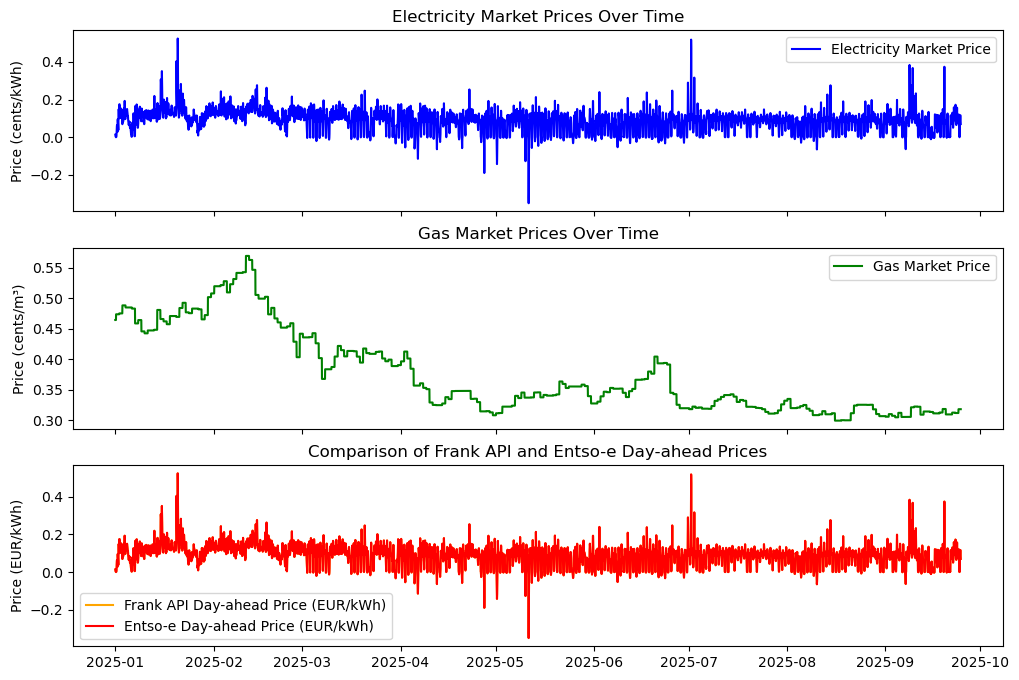

In [ ]:
#TODO: Plot the electricity and gas prices
# --- IGNORE ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax1.plot(pd.to_datetime(electricity_df['from']), electricity_df['marketPrice'], label='Electricity Market Price', color='blue')
ax1.set_title('Electricity Market Prices Over Time')
# --- IGNORE ---
ax1.set_ylabel('Price (cents/kWh)')
ax1.legend()
ax2.plot(pd.to_datetime(gas_df['from']), gas_df['marketPrice'], label='Gas Market Price', color='green')
ax2.set_title('Gas Market Prices Over Time')
ax2.set_ylabel('Price (cents/m³)')
ax2.legend()

ax3.plot(pd.to_datetime(merged['from']), merged['Frank API Day-ahead Price (EUR/kWh)'], label='Frank API Day-ahead Price (EUR/kWh)', color='orange')
ax3.plot(pd.to_datetime(merged['from']), merged['Entso-e Day-ahead Price (EUR/kWh)'], label='Entso-e Day-ahead Price (EUR/kWh)', color='red')
ax3.set_title('Comparison of Frank API and Entso-e Day-ahead Prices')
ax3.set_ylabel('Price (EUR/kWh)')
ax3.legend()



In [4]:
#export gas prices to parquet
gas_df.to_parquet('gas_prices.parquet', index=False)


In [5]:
#read the parquet file
gas_df_parquet = pd.read_parquet('gas_prices.parquet')
gas_df_parquet.head()

,from,till,marketPrice,marketPriceTax,sourcingMarkupPrice,energyTaxPrice,perUnit
0,2024-12-31T23:00:00.000Z,2025-01-01T00:00:00.000Z,0.46437,0.09752,0.07986,0.69957,M3
1,2025-01-01T00:00:00.000Z,2025-01-01T01:00:00.000Z,0.46437,0.09752,0.07986,0.69957,M3
2,2025-01-01T01:00:00.000Z,2025-01-01T02:00:00.000Z,0.46437,0.09752,0.07986,0.69957,M3
3,2025-01-01T02:00:00.000Z,2025-01-01T03:00:00.000Z,0.46437,0.09752,0.07986,0.69957,M3
4,2025-01-01T03:00:00.000Z,2025-01-01T04:00:00.000Z,0.46437,0.09752,0.07986,0.69957,M3
